In [55]:
import yfinance as yf
import pandas as pd

def create_equal_weighted_portfolio_returns(tickers, start_date, end_date):
    """
    Creates a DataFrame of daily returns for an equal-weighted portfolio from a list of tickers.

    Parameters:
    - tickers: List of stock tickers (strings)
    - start_date: Start date for data (string, e.g., '2020-01-01')
    - end_date: End date for data (string, e.g., '2023-01-01')

    Returns:
    - DataFrame with columns: 'portfolio_returns' (daily returns of the equal-weighted portfolio)
    """
    # Download historical price data
    data = yf.download(tickers, start=start_date, end=end_date, interval = '1mo')['Close']
    
    # Calculate daily returns for each stock
    returns = data.pct_change().dropna()
    
    # Calculate equal weights
    n = len(tickers)
    weights = [1/n] * n
    
    # Calculate portfolio returns (dot product of returns and weights)
    portfolio_returns = returns.dot(weights)
    
    # Return as DataFrame
    return pd.DataFrame({'portfolio_returns': portfolio_returns})

# Example usage:
tickers = ['AAPL', 'MSFT', 'GOOGL', 'ORCL']
start_date = '2022-01-01'
end_date = '2026-01-01'
portfolio_df = create_equal_weighted_portfolio_returns(tickers, start_date, end_date)
print(portfolio_df.head())

C:\Users\Hi\AppData\Local\Temp\ipykernel_12640\4260111939.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, end=end_date, interval = '1mo')['Close']
[*********************100%***********************]  4 of 4 completed

            portfolio_returns
Date                         
2022-02-01          -0.039190
2022-03-01           0.052873
2022-04-01          -0.122310
2022-05-01          -0.023905
2022-06-01          -0.050972


Shapiro-Wilk Test: Statistic=0.9741, p-value=0.3757
Jarque-Bera Test: Statistic=1.0999, p-value=0.5770
osm shape: (47,)
osr shape: (47,)
Slope:     0.067113
Intercept: 0.018112
R (corr):  0.990955
R²:        0.9820


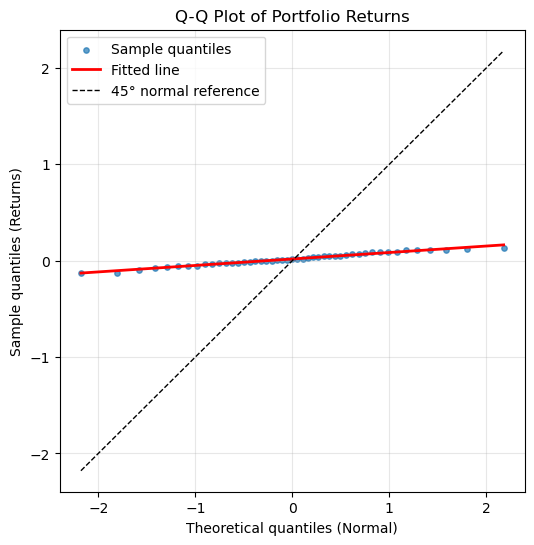

In [57]:
from scipy.stats import shapiro, jarque_bera
import matplotlib.pyplot as plt

# Example: portfolio_returns is a pandas Series of equal-weighted portfolio returns
stat, p = shapiro(portfolio_df)
print(f'Shapiro-Wilk Test: Statistic={stat:.4f}, p-value={p:.4f}')

# Jarque-Bera test (tests for skewness and kurtosis)
jb_stat, jb_p = jarque_bera(portfolio_df)
print(f'Jarque-Bera Test: Statistic={jb_stat:.4f}, p-value={jb_p:.4f}')

import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

r = portfolio_df['portfolio_returns'].dropna()

# probplot returns: (osm, osr), (slope, intercept, r)
(osm, osr), (slope, intercept, r) = stats.probplot(r, dist="norm", plot=None)

# Ensure 1-D
osm = np.asarray(osm).ravel()   # theoretical quantiles
osr = np.asarray(osr).ravel()   # ordered sample

print("osm shape:", osm.shape)  # should be (n,)
print("osr shape:", osr.shape)  # should be (n,)

print(f"Slope:     {slope:.6f}")
print(f"Intercept: {intercept:.6f}")
print(f"R (corr):  {r:.6f}")
print(f"R²:        {r**2:.4f}")

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(osm, osr, s=15, alpha=0.7, label="Sample quantiles")
fitted = intercept + slope * osm
plt.plot(osm, fitted, 'r-', lw=2, label="Fitted line")
plt.plot(osm, osm, 'k--', lw=1, label="45° normal reference")
plt.xlabel("Theoretical quantiles (Normal)")
plt.ylabel("Sample quantiles (Returns)")
plt.title("Q-Q Plot of Portfolio Returns")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [65]:
import numpy as np
import scipy.stats as stats

def interpret_normality_tests(returns, alpha=0.05):
    r = returns.dropna()

    # Shapiro–Wilk
    sh_stat, sh_p = stats.shapiro(r)

    # Jarque–Bera
    jb_stat, jb_p = stats.jarque_bera(r)

    # Q–Q (slope, intercept, correlation)
    (osm, osr), (slope, intercept, corr) = stats.probplot(r, dist="norm", plot=None)
    osm = np.asarray(osm).ravel()
    osr = np.asarray(osr).ravel()
    r2 = corr**2

    print(f"Shapiro-Wilk: statistic={sh_stat:.4f}, p-value={sh_p:.4f}")
    if sh_p < alpha:
        print("Interpretation: Reject normality at the "
              f"{alpha:.0%} level; the return distribution differs from normal.")
    else:
        print("Interpretation: Do NOT reject normality at the "
              f"{alpha:.0%} level; no strong evidence against a normal distribution.")

    print(f"\nJarque-Bera: statistic={jb_stat:.4f}, p-value={jb_p:.4f}")
    if jb_p < alpha:
        print("Interpretation: Reject normality based on skewness and kurtosis; "
              "returns show non-normal shape (skew and/or heavy tails).")
    else:
        print("Interpretation: Do NOT reject normality based on skewness and kurtosis; "
              "skew and tails are compatible with a normal distribution.")

    print(f"\nQ-Q line: slope={slope:.4f}, intercept={intercept:.4f}, "
          f"corr={corr:.4f}, R²={r2:.4f}")
    if abs(slope - 1) < 0.1 and r2 > 0.97:
        print("Interpretation: Q-Q points lie close to a 45° line; "
              "returns are well approximated by a normal distribution.")
    elif r2 > 0.9:
        print("Interpretation: Q-Q plot is roughly linear but not 45°; "
              "returns show some deviation from normality (e.g., mild skew or tail differences).")
    else:
        print("Interpretation: Q-Q plot is clearly non-linear; "
              "returns substantially depart from a normal distribution.")

# Example use:
interpret_normality_tests(portfolio_df['portfolio_returns'])

Shapiro-Wilk: statistic=0.9741, p-value=0.3757
Interpretation: Do NOT reject normality at the 5% level; no strong evidence against a normal distribution.

Jarque-Bera: statistic=1.0999, p-value=0.5770
Interpretation: Do NOT reject normality based on skewness and kurtosis; skew and tails are compatible with a normal distribution.

Q-Q line: slope=0.0671, intercept=0.0181, corr=0.9910, R²=0.9820
Interpretation: Q-Q plot is roughly linear but not 45°; returns show some deviation from normality (e.g., mild skew or tail differences).


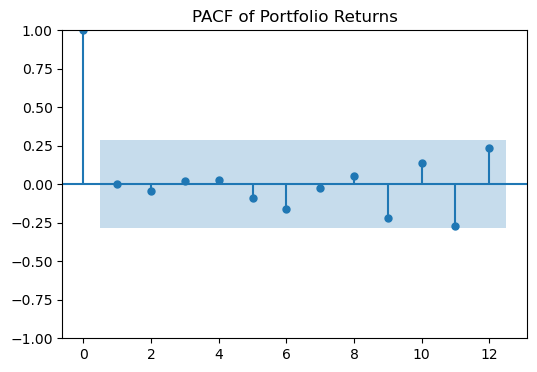

Ljung-Box (up to lag 12): statistic=11.0980, p-value=0.5205
→ Do NOT reject the null of no autocorrelation up to lag 12; the returns behave approximately like white noise (no strong serial correlation).
→ Interpretation of PACF: any bar that clearly exceeds the confidence band indicates a lag with significant partial autocorrelation; if all bars lie within the band, there is no strong evidence of AR structure.


In [70]:
import numpy as np
import pandas as pd
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import matplotlib.pyplot as plt

def interpret_pacf_and_lb(returns, alpha=0.05, max_lag=12):
    """
    Plot PACF and run Ljung–Box test for a return series.
    Prints an English interpretation of serial dependence.
    """
    r = returns.dropna()

    # ----- PACF plot -----
    fig, ax = plt.subplots(figsize=(6, 4))
    plot_pacf(r, lags=max_lag, ax=ax, method="ywm")  # standard PACF estimator [web:186][web:195]
    plt.title("PACF of Portfolio Returns")
    plt.show()

    # ----- Ljung–Box joint test for autocorrelation up to max_lag -----
    lb = acorr_ljungbox(r, lags=[max_lag], return_df=True)  # [web:187][web:190]
    lb_stat = lb["lb_stat"].iloc[0]
    lb_p = lb["lb_pvalue"].iloc[0]

    print(f"Ljung-Box (up to lag {max_lag}): statistic={lb_stat:.4f}, p-value={lb_p:.4f}")

    if lb_p < alpha:
        print(f"→ Reject the null of no autocorrelation up to lag {max_lag}; "
              "the return series shows significant serial dependence.")
    else:
        print(f"→ Do NOT reject the null of no autocorrelation up to lag {max_lag}; "
              "the returns behave approximately like white noise (no strong serial correlation).")

    print("→ Interpretation of PACF: any bar that clearly exceeds the confidence band "
          "indicates a lag with significant partial autocorrelation; "
          "if all bars lie within the band, there is no strong evidence of AR structure.")

# Example:
interpret_pacf_and_lb(portfolio_df['portfolio_returns'], alpha=0.05, max_lag=12)